# 🐝 Brentford FC Football Analytics Project

----
**👤 Student:** Ahmed Chakcha - Mohamed Ali Djemal  

**📈 Course:** Data Analysis

**🎓 Instructor:** Dr. Khalil Masmoudi

**📅 Academic Year:** 2025-2026


##  Introduction

This project focuses on analyzing Brentford FC’s performance over the period 2021 to 2026 using a dataset sourced from [Kaggle](https://kaggle.com/datasets/543718cc009af71cc9dc369fb12aa33f8c5369747315f1ccece2749811839f2a). The objective is to explore match results, team statistics, and key performance indicators in order to understand how the club has evolved across recent seasons.

By applying data analysis and visualization techniques, we aim to transform raw football data into meaningful insights. This will help identify important trends, performance patterns, and the main factors influencing match outcomes over time.

## Objectives

The objectives of this project are :

* Analyze Brentford FC performance over the period 2021–2026 using real match data from Kaggle.

* Explore and understand key match statistics such as goals scored, goals conceded, wins, losses, and draws.

* Identify performance trends across different seasons and detect improvements or declines over time.

* Visualize data using charts to make patterns and insights easier to understand.
* Compare different ML models to evaluate performance.


---
## Part 1 — Setup & Data Loading

This section imports all required libraries, defines the club's visual identity colours,
and sets global Matplotlib rendering parameters for consistent, publication-quality figures.

#### 1.1 Library Imports

In [2]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import scipy.stats as stats
from scipy.linalg import svd as sp_svd
from scipy.stats import norm, chi2_contingency, mannwhitneyu,chi2,norm
from scipy.stats import t as t_dist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)
import xgboost as xgb
from xgboost import XGBClassifier
import statsmodels.api as sm


### 1.2 Global Style Configuration

Brentford FC brand colours: **Red** `#E30613` and **Gold** `#F7B500`.  
All figures use these colours for consistency with the club's visual identity.

In [3]:
# ── Brentford brand palette
BLUE  = '#185FA5'
GREEN = '#1D9E75'
LIGHT = '#E6F1FB'
RED  = '#E30613'
GOLD = '#F7B500'
DARK = '#1A1A2E'
GREY = '#6C757D'
BMAP = LinearSegmentedColormap.from_list('brentford', [DARK, '#FFFFFF', RED], N=256)
# ── Global Matplotlib parameters
plt.rcParams.update({
    'figure.facecolor' : '#F8F9FA',
    'axes.facecolor'   : '#FFFFFF',
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'figure.dpi'       : 110
})

np.random.seed(42)

### 1.3 Data Loading

In [4]:
df = pd.read_csv('/content/sample_data/brentford_2021_2026_clean.csv')

# Data Shape
shape=df.shape
print(f"The dataset has {shape[0]} rows and {shape[1]} columns.")


The dataset has 4151 rows and 56 columns.


In [5]:
# Dataset Informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4151 entries, 0 to 4150
Data columns (total 56 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                4151 non-null   int64  
 1   date                    4151 non-null   object 
 2   season                  4151 non-null   object 
 3   team                    4151 non-null   object 
 4   opponent                4151 non-null   object 
 5   venue                   4151 non-null   object 
 6   competition             4151 non-null   object 
 7   result                  4151 non-null   object 
 8   goals_for               4151 non-null   int64  
 9   goals_against           4151 non-null   int64  
 10  team_xG                 0 non-null      float64
 11  opponent_xG             0 non-null      float64
 12  possession              4151 non-null   int64  
 13  total_shots             4151 non-null   int64  
 14  shots_on_target         4151 non-null   

In [6]:
# Dataset Overview
df.head(5)

,match_id,date,season,team,opponent,venue,competition,result,goals_for,goals_against,...,ball_recoveries,duels_won,duels_lost,aerial_duels_won,aerial_duels_lost,fouls_committed_player,fouls_suffered,offsides,saves,rating
0,1,2021-11-06,21/22,Brentford,Norwich City,Home,Premier League,L,1,2,...,10,0,0,0,0,0,0,0,4,6.6
1,1,2021-11-06,21/22,Brentford,Norwich City,Home,Premier League,L,1,2,...,0,0,0,0,0,0,0,0,0,6.4
2,1,2021-11-06,21/22,Brentford,Norwich City,Home,Premier League,L,1,2,...,5,4,1,4,1,0,0,0,0,6.9
3,1,2021-11-06,21/22,Brentford,Norwich City,Home,Premier League,L,1,2,...,5,15,4,7,4,0,2,0,0,7.9
4,1,2021-11-06,21/22,Brentford,Norwich City,Home,Premier League,L,1,2,...,11,3,5,0,1,1,0,0,0,6.8


### 1.4 Data  Preprocessing

In [7]:
df['date'] = pd.to_datetime(df['date'])

# Target encodings
df['result_win']  = (df['result'] == 'W').astype(int)
df['result_code'] = df['result'].map({'W': 2, 'D': 1, 'L': 0})

#  Missing value imputation
df['red_cards']    = df['red_cards'].fillna(0)
df['yellow_cards'] = df.groupby('position')['yellow_cards'] \
                       .transform(lambda x: x.fillna(x.median()))

In [8]:
#  Derived individual metrics

df['pass_acc']  = np.where(df['total_passes'] > 0, df['accurate_passes'] / df['total_passes'] * 100, 0)

df['drib_succ'] = np.where(df['dribbles_attempted'] > 0,df['dribbles_completed'] / df['dribbles_attempted'] * 100, 0)

df['def_score'] = (df['tackles_won'] + df['interceptions'] + df['clearances']  + df['blocks'])

df['goal_inv']  = df['goals'] + df['assists']


In [9]:
# Match-level table

MATCH_COLS = ['match_id', 'date', 'season', 'venue', 'competition',
              'result', 'result_win', 'result_code',
              'goals_for', 'goals_against', 'possession',
              'total_shots', 'shots_on_target', 'corners', 'fouls_committed']

match = df.drop_duplicates('match_id')[MATCH_COLS].copy()
match['season_n'] = match['season'].map(
    {'21/22': 1, '22/23': 2, '23/24': 3, '24/25': 4, '25/26': 5})

In [10]:
print(f"Match table   : {match.shape[0]} rows × {match.shape[1]} columns")
print(f"Players       : {df.player_name.nunique()}")
print(f"Date range    : {df.date.min().date()} → {df.date.max().date()}")

Match table   : 208 rows × 16 columns
Players       : 81
Date range    : 2021-08-13 → 2026-03-21


---

## Part 2 — EDA & Descriptive Statistics

Exploratory Data Analysis (EDA) is the essential first step before any modelling.  
We examine the data from three angles:
1. **Data quality** — residual missing values after preprocessing
2. **Statistical profile** — distribution shape, variability, skewness
3. **Football performance** — season-by-season trends and top player leaderboard

### 2.1 Residual Missing Value Audit

After preprocessing, we verify which columns still contain null values.  
Only columns with at least one missing value are shown.

In [11]:
miss     = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)

miss_df = pd.DataFrame({'Count': miss, 'Pct %': miss_pct})
miss_df = miss_df[miss_df['Count'] > 0].sort_values('Pct %', ascending=False)

print(miss_df.to_string())
print(f"\n {df.shape[1] - len(miss_df)} / {df.shape[1]} columns are complete")

             Count   Pct %
team_xG       4151  100.00
opponent_xG   4151  100.00
rating        1083   26.09

 59 / 62 columns are complete


### 2.2 Extended Descriptive Statistics

Standard `describe()` is augmented with:
- **Skewness** — asymmetry of the distribution
- **Kurtosis** — tail heaviness (>3 = leptokurtic; <3 = platykurtic)
- **Coefficient of Variation (CV%)** — relative dispersion (std / mean × 100)

> Most football counting statistics are **right-skewed** (many zeros, few large values),
> which motivates the use of non-parametric tests in Part 4.

In [12]:
STAT_COLS = ['minutes_played', 'goals', 'assists', 'shots', 'touches',
             'total_passes', 'key_passes', 'tackles', 'tackles_won',
             'interceptions', 'clearances', 'duels_won', 'aerial_duels_won',
             'rating', 'pass_acc', 'def_score', 'goal_inv']

desc = df[STAT_COLS].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc['skew'] = df[STAT_COLS].skew()
desc['kurt'] = df[STAT_COLS].kurt()
desc['CV%']  = (df[STAT_COLS].std() / df[STAT_COLS].mean() * 100).round(1)

with pd.option_context('display.float_format', '{:.3f}'.format):
    print(desc.to_string())

                    count   mean    std   min    5%   25%    50%    75%     95%     max   skew   kurt     CV%
minutes_played   4151.000 49.929 39.393 0.000 0.000 1.000 67.000 90.000  90.000 120.000 -0.191 -1.767  78.900
goals            4151.000  0.074  0.301 0.000 0.000 0.000  0.000  0.000   1.000   4.000  4.925 30.971 407.200
assists          4151.000  0.050  0.230 0.000 0.000 0.000  0.000  0.000   0.000   2.000  4.779 23.930 460.300
shots            4151.000  0.579  1.055 0.000 0.000 0.000  0.000  1.000   3.000   9.000  2.552  8.673 182.300
touches          4151.000 29.751 26.476 0.000 0.000 0.000 29.000 49.500  76.000 122.000  0.531 -0.548  89.000
total_passes     4151.000 20.364 20.231 0.000 0.000 0.000 16.000 33.000  59.000 107.000  0.972  0.572  99.400
key_passes       4151.000  0.424  0.829 0.000 0.000 0.000  0.000  1.000   2.000   7.000  2.572  8.663 195.500
tackles          4151.000  0.800  1.228 0.000 0.000 0.000  0.000  1.000   3.000  10.000  1.975  4.841 153.500
tackles_wo

### 2.3 Season-by-Season Summary

Aggregated match-level statistics per season. Metrics: win count, win rate,
average goals for/against, possession, total shots, shots on target.

In [13]:
season_summary = match.groupby('season').agg(
    Matches  = ('match_id',   'count'),
    Wins     = ('result_win', 'sum'),
    WinPct   = ('result_win', 'mean'),
    GF       = ('goals_for',  'mean'),
    GA       = ('goals_against', 'mean'),
    Poss     = ('possession', 'mean'),
    Shots    = ('total_shots', 'mean'),
).round(3)

print(season_summary.to_string())

        Matches  Wins  WinPct     GF     GA    Poss   Shots
season                                                     
21/22        44    17   0.386  1.477  1.477  45.682  11.909
22/23        41    16   0.390  1.610  1.317  45.293  10.902
23/24        42    11   0.262  1.500  1.690  46.190  12.619
24/25        43    19   0.442  1.791  1.558  49.698  11.535
25/26        38    18   0.474  1.737  1.421  48.105  10.658


---
### 2.4 — Data Visualisation Overview

In this section, we use a set of visualizations to better understand the dataset and uncover key patterns and trends. The following charts will help provide clearer insights into performance and support a deeper analysis.

* Match Results per Season

    Shows the distribution of wins, draws, and losses across seasons, helping track overall team performance trends over time.

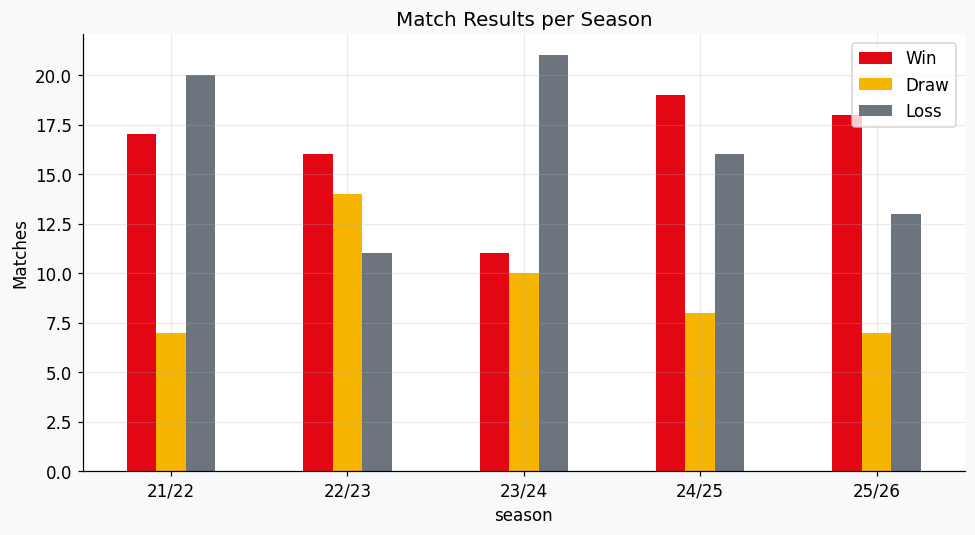

In [14]:
res = match.groupby(['season', 'result']).size().unstack(fill_value=0).reindex(['21/22','22/23','23/24','24/25','25/26'])

res[['W','D','L']].plot(kind='bar', color=[RED, GOLD, GREY], figsize=(9,5))
plt.title('Match Results per Season')
plt.ylabel('Matches')
plt.xticks(rotation=0)
plt.legend(['Win','Draw','Loss'])
plt.tight_layout()
plt.show()

* Home vs Away Win Rate

    Highlights the difference in win percentage between home and away matches, indicating home advantage impact.



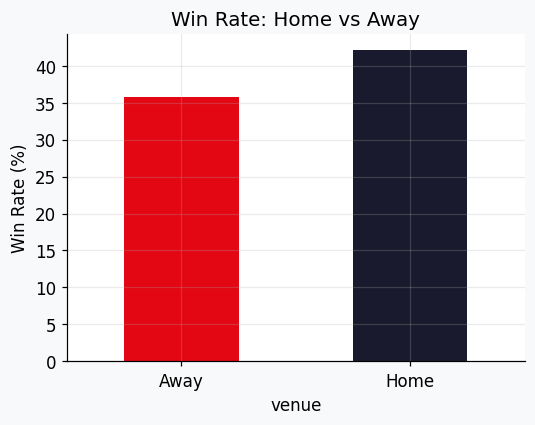

In [15]:
hva = match.groupby('venue')['result_win'].mean() * 100

hva.plot(kind='bar', color=[RED, DARK], figsize=(5,4))
plt.title('Win Rate: Home vs Away')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* Goals For vs Against per Season

    Compares the average goals scored and conceded per season to evaluate offensive and defensive consistency.

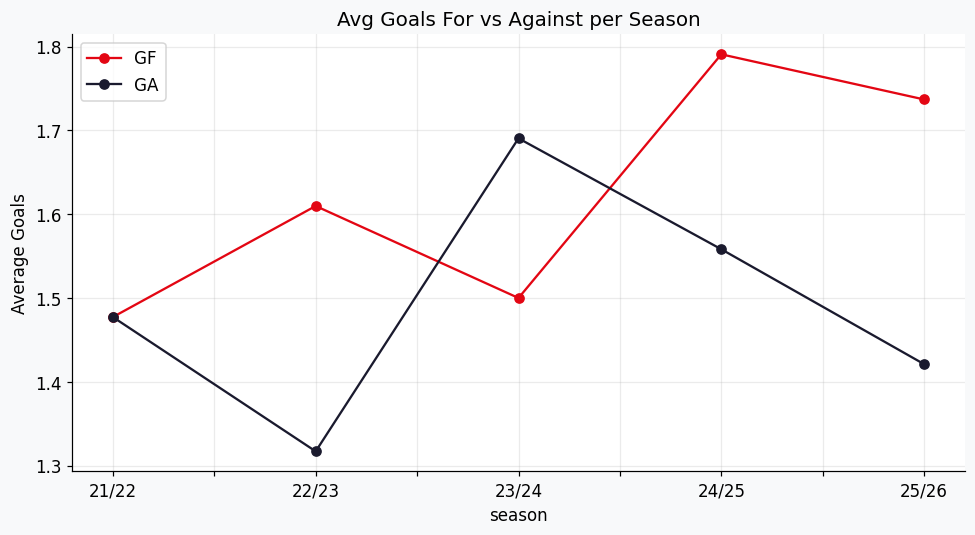

In [16]:
gf_ga = match.groupby('season').agg(GF=('goals_for','mean'), GA=('goals_against','mean')).reindex(['21/22','22/23','23/24','24/25','25/26'])

gf_ga.plot(kind='line', marker='o', color=[RED, DARK], figsize=(9,5))
plt.title('Avg Goals For vs Against per Season')
plt.ylabel('Average Goals')
plt.tight_layout()
plt.show()

* Possession vs Win Rate

    Examines the relationship between possession levels and win rate to understand if higher possession leads to better results.

/tmp/ipykernel_4246/3473471249.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poss_win = match.groupby('poss_bucket')['result_win'].mean() * 100


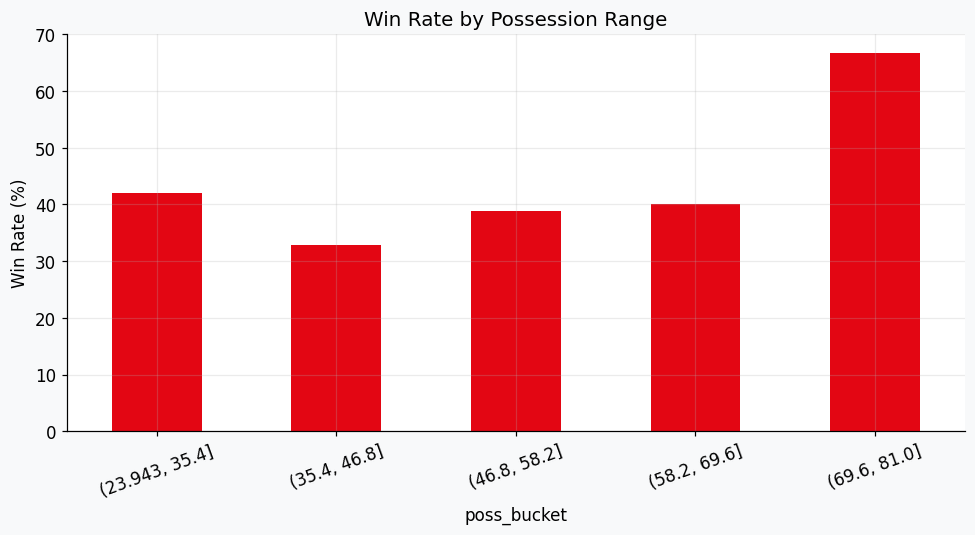

In [17]:
match['poss_bucket'] = pd.cut(match['possession'], bins=5)
poss_win = match.groupby('poss_bucket')['result_win'].mean() * 100

poss_win.plot(kind='bar', color=RED, figsize=(9,5))
plt.title('Win Rate by Possession Range')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

* Squad Usage by Position

    Illustrates how each position contributes to the team, comparing total appearances and average minutes played to understand player utilization and role importance.

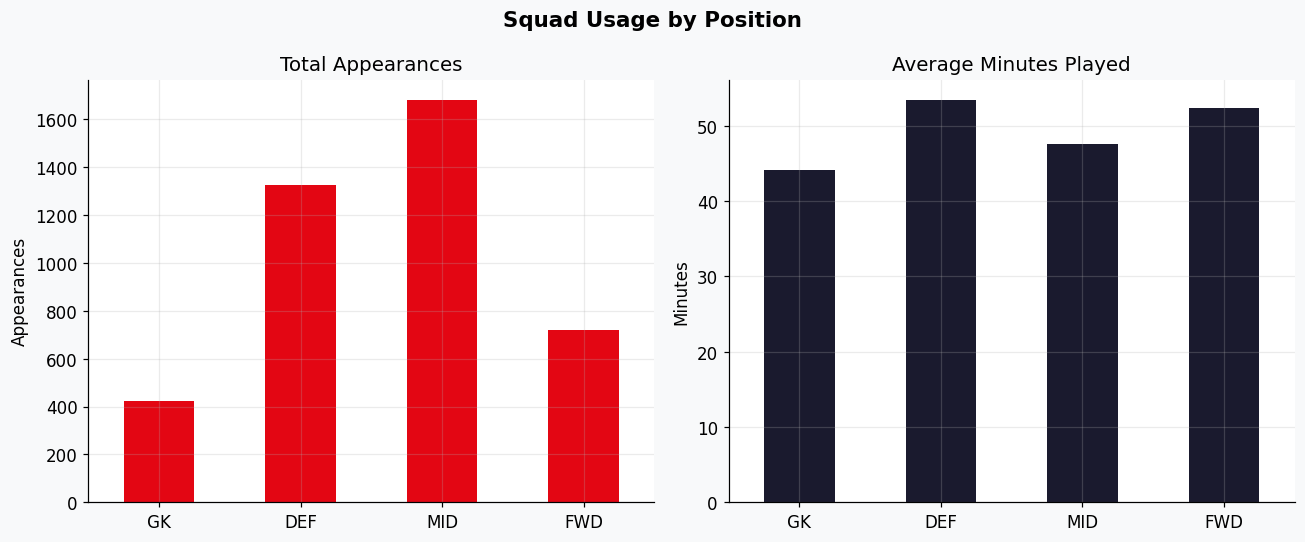

In [18]:
pos_stats = df.groupby('position').agg(
    Appearances=('player_name', 'count'),
    AvgMinutes=('minutes_played', 'mean')
).reindex(['G','D','M','F'])
pos_stats.index = ['GK','DEF','MID','FWD']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Squad Usage by Position', fontsize=14, fontweight='bold')

pos_stats['Appearances'].plot(kind='bar', ax=axes[0], color=RED, width=0.5)
axes[0].set_title('Total Appearances')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylabel('Appearances')

pos_stats['AvgMinutes'].plot(kind='bar', ax=axes[1], color=DARK, width=0.5)
axes[1].set_title('Average Minutes Played')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

* Top 10 Players by Goal Involvement

    Displays the most impactful players based on total goals and assists, identifying key contributors in attack.

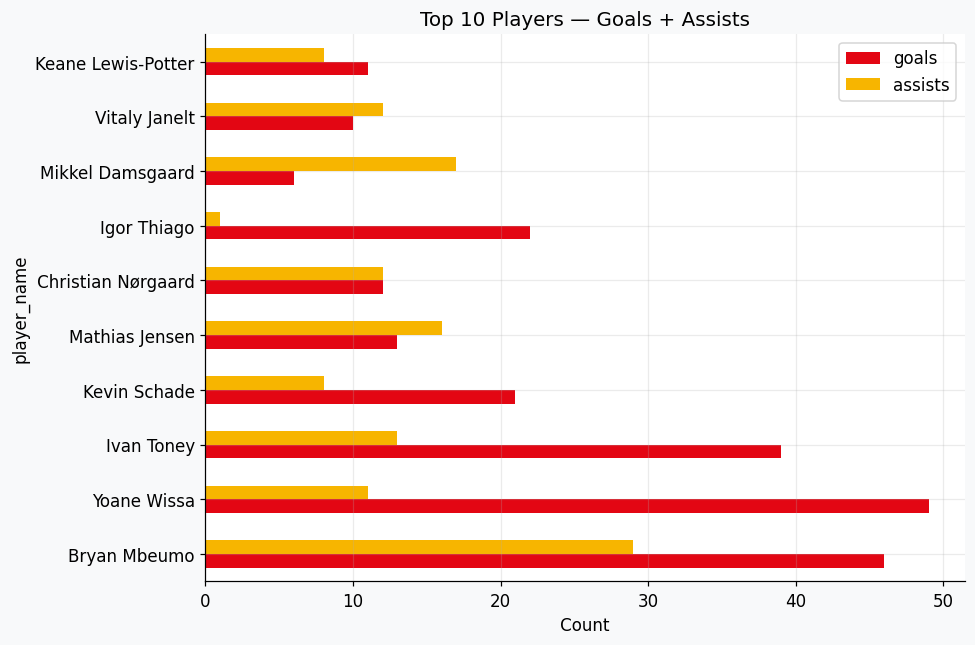

In [19]:
top10 = df.groupby('player_name')[['goals','assists']].sum()
top10['total'] = top10['goals'] + top10['assists']
top10 = top10.nlargest(10, 'total')

top10[['goals','assists']].plot(kind='barh', color=[RED, GOLD], figsize=(9,6))
plt.title('Top 10 Players — Goals + Assists')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

---

### 2.5 — Correlation Deep Dive

Before reducing dimensions , we measure which player statistics
are strongly related to each other. High correlation between variables
confirms that PCA is appropriate — redundant variables carry the same
information and can be compressed into fewer dimensions.

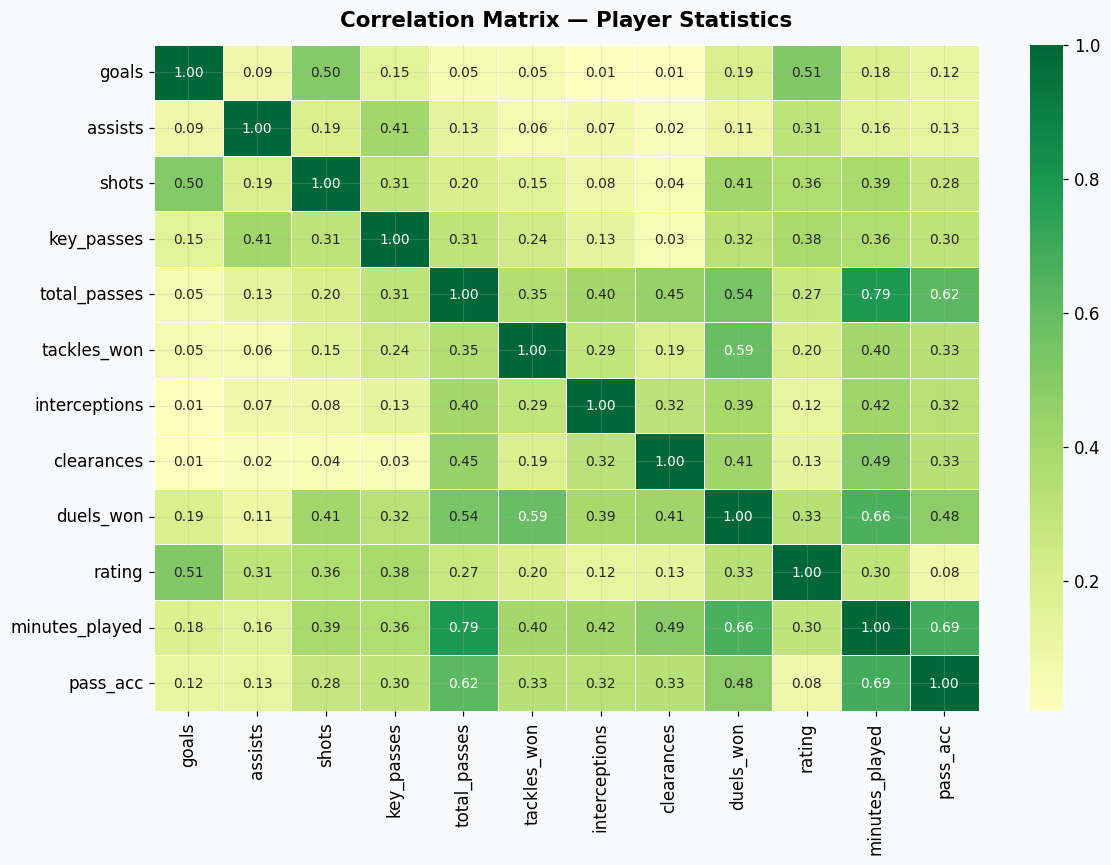

In [20]:
CORR_COLS = ['goals', 'assists', 'shots', 'key_passes', 'total_passes',
             'tackles_won', 'interceptions', 'clearances',
             'duels_won', 'rating', 'minutes_played', 'pass_acc']

corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Player Statistics',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


> Interpretation



 The strongest relationships are between **total_passes** ↔ **minutes_played** (0.79) and **minutes_played** ↔ **pass_acc** (0.69), meaning players who play more are naturally more involved and accurate.

  Attacking stats like **goals** ↔ **shots** (0.50) are linked while defensive stats like interceptions and clearances show no relationship with goals (0.01), confirming players operate in completely different statistical spaces by position.


* ####  Player-Level Distributions

Each row in `df` represents one player in one match (4,151 records).
These distributions show how individual statistics are spread across all players —
revealing skewness, outliers, and the split between starters and substitutes.

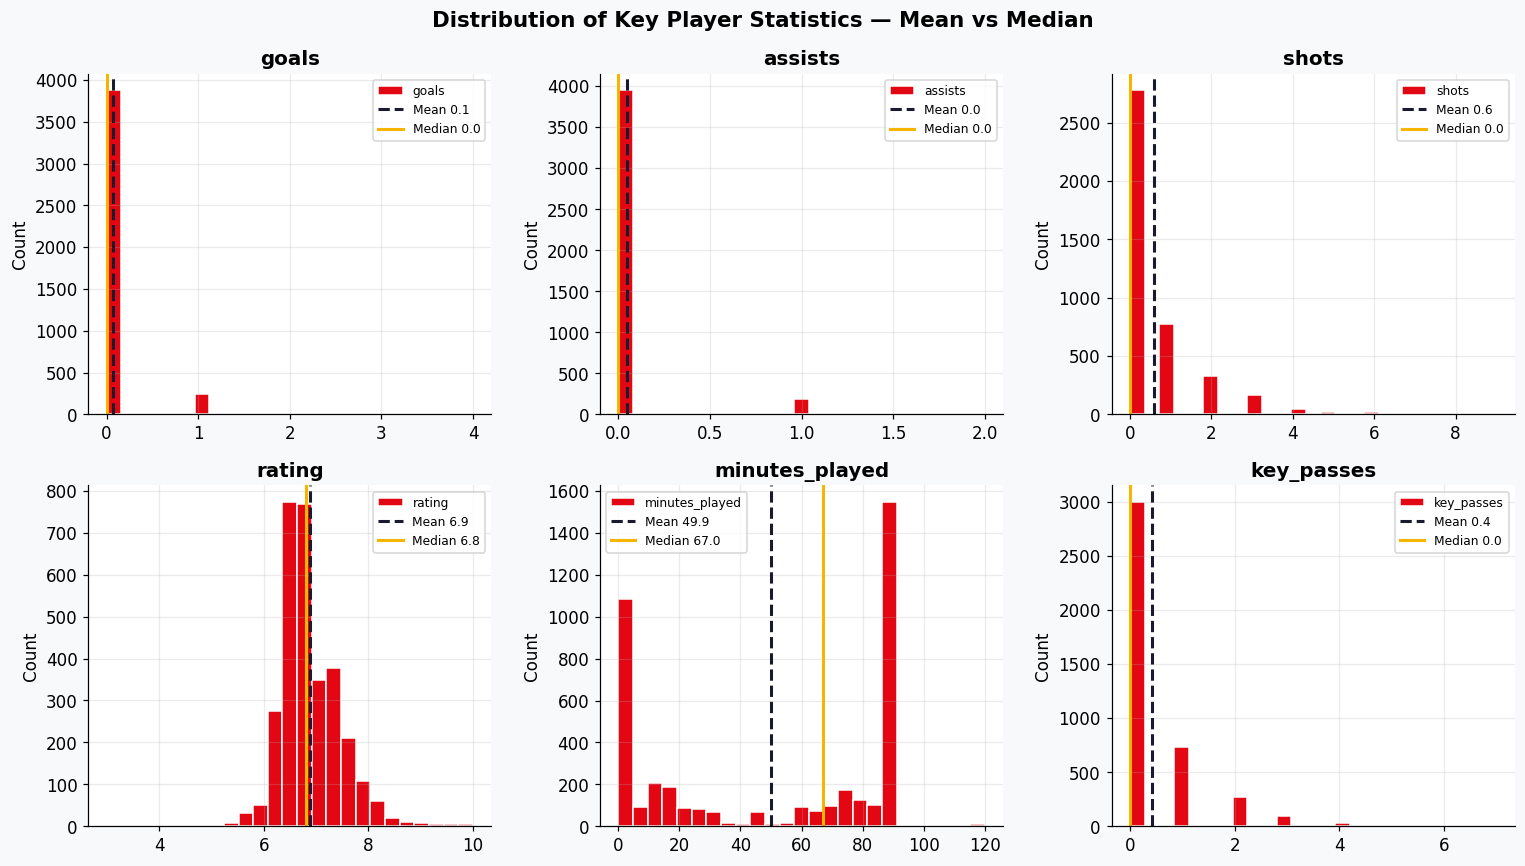

In [21]:
DIST_COLS = ['goals', 'assists', 'shots', 'rating', 'minutes_played', 'key_passes']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribution of Key Player Statistics — Mean vs Median',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), DIST_COLS):
    df[col].dropna().plot(kind='hist', bins=25, ax=ax, color=RED, edgecolor='white')
    ax.axvline(df[col].mean(),   color=DARK, linestyle='--', lw=2,
               label=f'Mean {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color=GOLD, linestyle='-',  lw=2,
               label=f'Median {df[col].median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

> Interpretation

Goals, assists, shots and key_passes are all heavily right-skewed with median = 0.0 — most players contribute nothing in a given match and a few drive all the numbers. minutes_played shows a clear bimodal split between substitutes (0–10 min) and starters (85–90 min). Only rating is close to normal, centred around 6.8.

* Team-Level Distributions

Each row in `match` represents one match (208 records).
These distributions show how the team performs as a unit per game —
goals, shots, possession and corners across all 5 seasons.
Combined with player distributions, this gives a complete picture

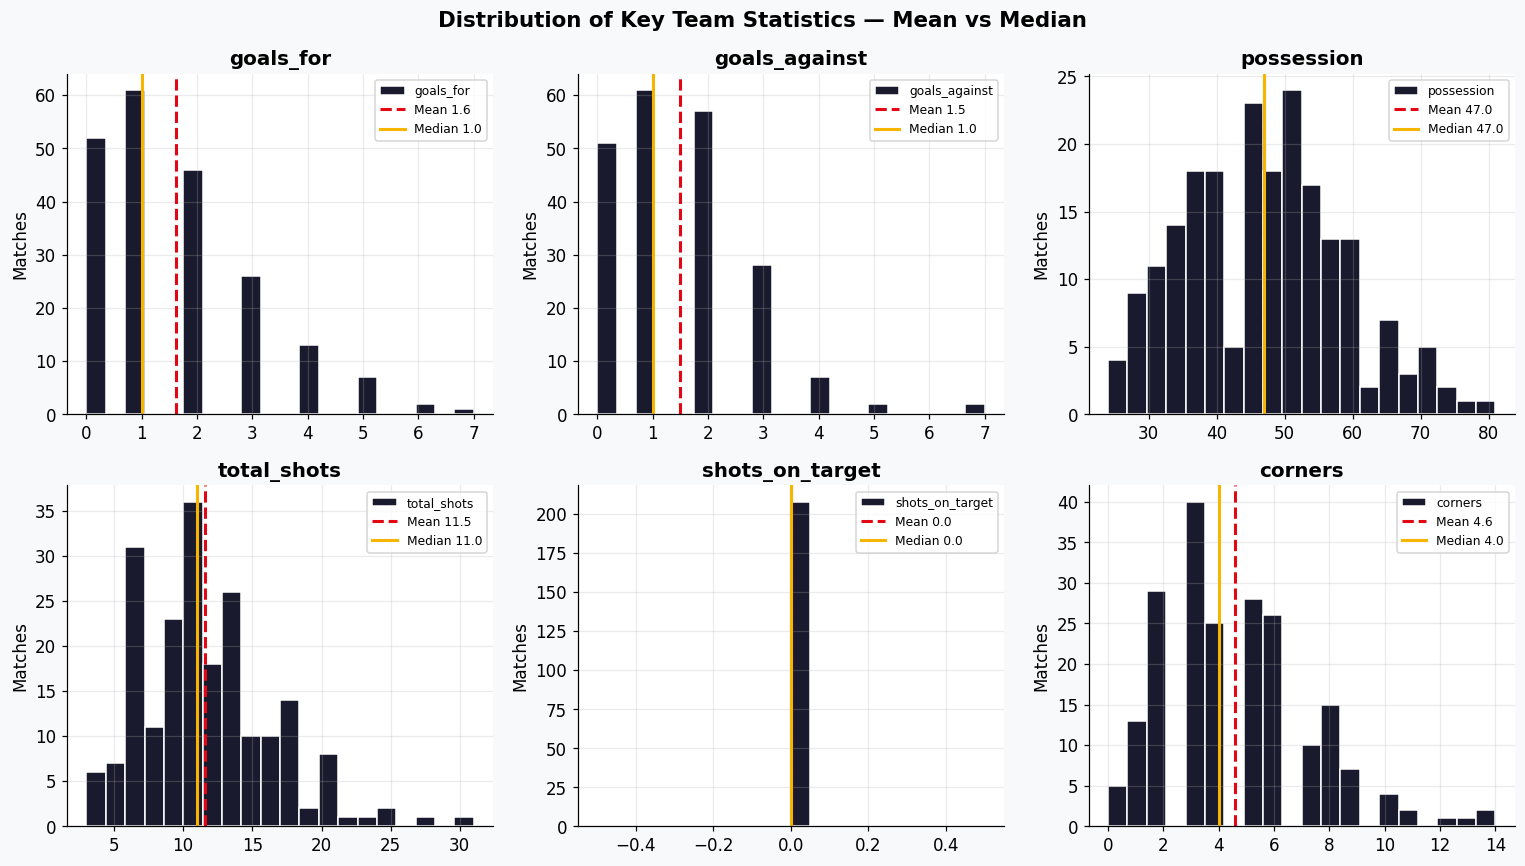

In [22]:
TEAM_COLS = ['goals_for', 'goals_against', 'possession',
             'total_shots', 'shots_on_target', 'corners']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribution of Key Team Statistics — Mean vs Median',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), TEAM_COLS):
    match[col].dropna().plot(kind='hist', bins=20, ax=ax, color=DARK, edgecolor='white')
    ax.axvline(match[col].mean(),   color=RED,  linestyle='--', lw=2,
               label=f'Mean {match[col].mean():.1f}')
    ax.axvline(match[col].median(), color=GOLD, linestyle='-',  lw=2,
               label=f'Median {match[col].median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Matches')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

>  Interpretation

Goals scored and conceded are right-skewed with median = 1.0 — Brentford most commonly scores and concedes exactly one goal per match. possession is the most symmetric, consistently around 47% across all 208 matches. total_shots is centred around 10–11 per match.

---

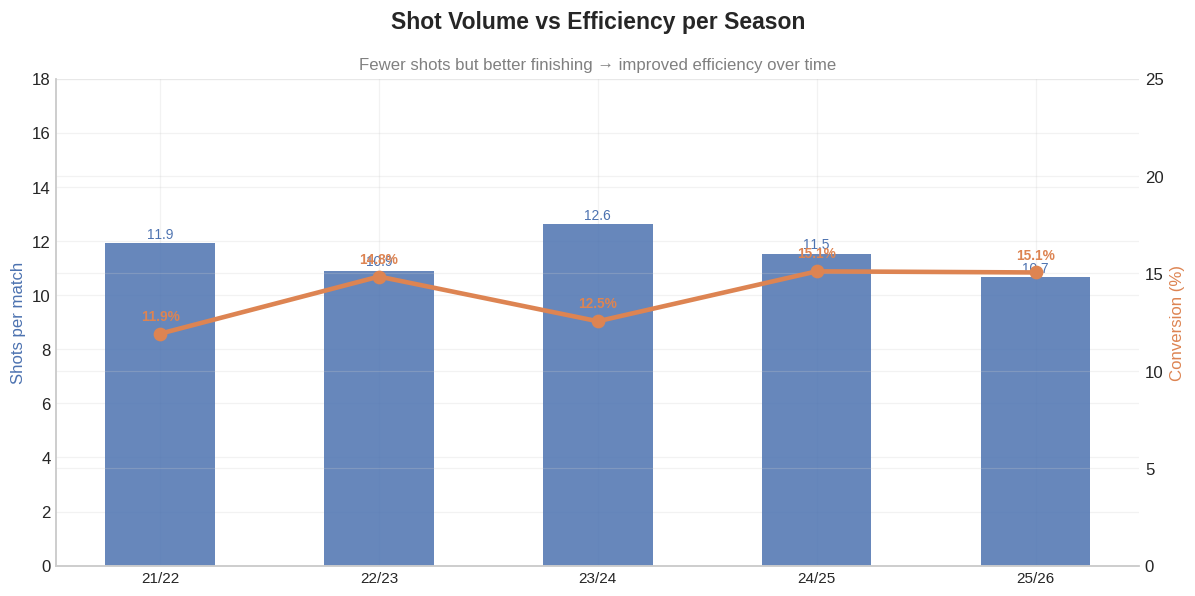

In [52]:

plt.style.use('seaborn-v0_8-whitegrid')

BLUE = '#4C72B0'
RED = '#DD8452'

SEASON_ORDER = ['21/22', '22/23', '23/24', '24/25', '25/26']

match['shot_conv'] = (match['goals_for'] / match['total_shots'] * 100).round(2)

season_stats = (
    match.groupby('season')
    .agg(
        ShotConv=('shot_conv', 'mean'),
        AvgShots=('total_shots', 'mean')
    )
    .reindex(SEASON_ORDER)
)
fig, ax1 = plt.subplots(figsize=(11, 5.5))

x = np.arange(len(SEASON_ORDER))

# ---- Bars (Shots) ----
bars = ax1.bar(
    x,
    season_stats['AvgShots'],
    width=0.5,
    color=BLUE,
    alpha=0.85
)

ax1.set_ylabel('Shots per match', fontsize=11, color=BLUE)
ax1.set_xticks(x)
ax1.set_xticklabels(SEASON_ORDER, fontsize=10)
ax1.set_ylim(0, 18)

# Clean look
ax1.spines[['top', 'right']].set_visible(False)

# Bar labels
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}',
        ha='center',
        fontsize=9,
        color=BLUE
    )

# ---- Line (Conversion) ----
ax2 = ax1.twinx()
ax2.plot(
    x,
    season_stats['ShotConv'],
    color=RED,
    marker='o',
    linewidth=3,
    markersize=8
)

ax2.set_ylabel('Conversion (%)', fontsize=11, color=RED)
ax2.set_ylim(0, 25)
ax2.spines['top'].set_visible(False)

# Line labels
for i, v in enumerate(season_stats['ShotConv']):
    ax2.text(
        i,
        v + 0.7,
        f'{v:.1f}%',
        ha='center',
        fontsize=9,
        color=RED,
        fontweight='bold'
    )

fig.suptitle(
    'Shot Volume vs Efficiency per Season',
    fontsize=15,
    fontweight='bold'
)

ax1.set_title(
    'Fewer shots but better finishing → improved efficiency over time',
    fontsize=11,
    color='gray'
)

plt.tight_layout()
plt.show()

## Part 3 — Advanced Statistical Methods

In Part 2 we described and visualised the data. Now we go deeper.
This part applies three methods to uncover the hidden structure of the dataset
before moving to hypothesis testing in Part 4.

We start by identifying exceptional and underperforming players (3.1),
then compress the 15 correlated player statistics into key dimensions (3.2),
group players into performance archetypes (3.3) and finally measures inequality of offensive contribution (3.4)

| Method             | Purpose                                          |
| ------------------ | ------------------------------------------------ |
| Outlier Detection  | Identify exceptional and underperforming players |
| PCA                | Compress 15 correlated stats into key dimensions |
| K-Means Clustering | Group 81 players into performance archetypes     |
| Lorenz Curve & Gini Coefficient | Measures inequality of offensive contribution|



### 3.1 Outlier Detection

We use the Z-score method to identify players who perform significantly
above or below the squad average in key statistics.
A Z-score above 2.5 or below -2.5 flags a player as an outlier —
meaning they are far from what is typical across the squad.
This identifies exceptional performers and underperformers before PCA and clustering.


In [23]:
from scipy.stats import zscore

OUTLIER_COLS = ['goals', 'assists', 'shots', 'rating',
                'minutes_played', 'key_passes', 'tackles_won']

player_avg = df.groupby('player_name')[OUTLIER_COLS].mean()
z_scores   = player_avg.apply(zscore)

outliers        = (z_scores.abs() > 2.5).any(axis=1)
outlier_players = player_avg[outliers].copy()
outlier_players['flagged_stats'] = z_scores[outliers].apply(
    lambda row: row[row.abs() > 2.5].index.tolist(), axis=1)

print(f"Total outlier players detected: {outliers.sum()}\n")
print(outlier_players[OUTLIER_COLS].round(2).to_string())

Total outlier players detected: 8

                    goals  assists  shots  rating  minutes_played  key_passes  tackles_won
player_name                                                                               
Bryan Mbeumo         0.31     0.20   2.01    7.17           78.68        1.35         0.53
Christian Eriksen    0.09     0.36   2.00    7.54           85.27        2.82         0.55
Christian Nørgaard   0.09     0.09   0.95    7.04           80.73        0.66         1.52
Igor Thiago          0.52     0.02   1.81    6.95           70.90        0.50         0.55
Ivan Toney           0.43     0.14   2.76    7.22           83.86        0.96         0.45
Michael Kayode       0.02     0.02   0.24    6.90           70.38        0.80         1.08
Sergio Reguilón      0.00     0.25   0.81    6.93           70.12        1.25         1.25
Yoane Wissa          0.32     0.07   1.66    6.96           59.34        0.59         0.34


>  Interpretation


8 players out of 81 were flagged as outliers. Attacking output is driven by Toney (2.76 shots), Mbeumo, Wissa and Igor Thiago. Eriksen stands alone creatively with the highest key passes (2.82) and rating (7.54). Defensively, Nørgaard, Kayode and Reguilón dominate tackles won.

### 3.2 Principal Component Analysis (PCA)

The correlation matrix in Part 2.5 showed strong overlap between several
player statistics. PCA takes these 15 correlated variables and rotates them
into a smaller number of independent components that together explain 90%
of the total variance.

The scree plot shows how many components are needed
and the biplot shows how players separate by position in this compressed space.

In [24]:
PCA_FEATS = ['minutes_played', 'goals', 'assists', 'shots', 'touches',
             'total_passes', 'key_passes', 'tackles', 'tackles_won',
             'interceptions', 'clearances', 'duels_won', 'aerial_duels_won',
             'def_score', 'goal_inv']

sub = df[PCA_FEATS + ['position', 'rating']].dropna(subset=['rating'])
Xs  = StandardScaler().fit_transform(sub[PCA_FEATS].fillna(0))

pca = PCA(random_state=42).fit(Xs)
ev  = pca.explained_variance_ratio_
cv  = ev.cumsum()
Xp  = pca.transform(Xs)

n_keep = (cv >= 0.90).argmax() + 1
print(f"Components to reach 90% variance : {n_keep}")
print(f"Variance explained by PC1        : {ev[0]*100:.1f}%")
print(f"Variance explained by PC1 + PC2  : {cv[1]*100:.1f}%\n")

loadings = pd.DataFrame(pca.components_[:3].T,
                        index=PCA_FEATS,
                        columns=['PC1','PC2','PC3']).round(3)
print("Loadings sorted by PC1:")
print(loadings.reindex(loadings['PC1'].abs()
                       .sort_values(ascending=False).index).to_string())

Components to reach 90% variance : 8
Variance explained by PC1        : 31.5%
Variance explained by PC1 + PC2  : 49.0%

Loadings sorted by PC1:
                    PC1    PC2    PC3
touches           0.380 -0.030 -0.181
def_score         0.357 -0.201 -0.069
duels_won         0.354  0.065  0.201
minutes_played    0.351  0.041 -0.166
total_passes      0.330 -0.070 -0.236
aerial_duels_won  0.276 -0.008 -0.213
clearances        0.271 -0.197 -0.298
tackles           0.268 -0.020  0.578
tackles_won       0.248 -0.028  0.587
interceptions     0.227 -0.113  0.001
key_passes        0.117  0.289  0.103
shots             0.098  0.406 -0.016
goal_inv          0.077  0.559 -0.084
assists           0.061  0.352 -0.048
goals             0.053  0.459 -0.073


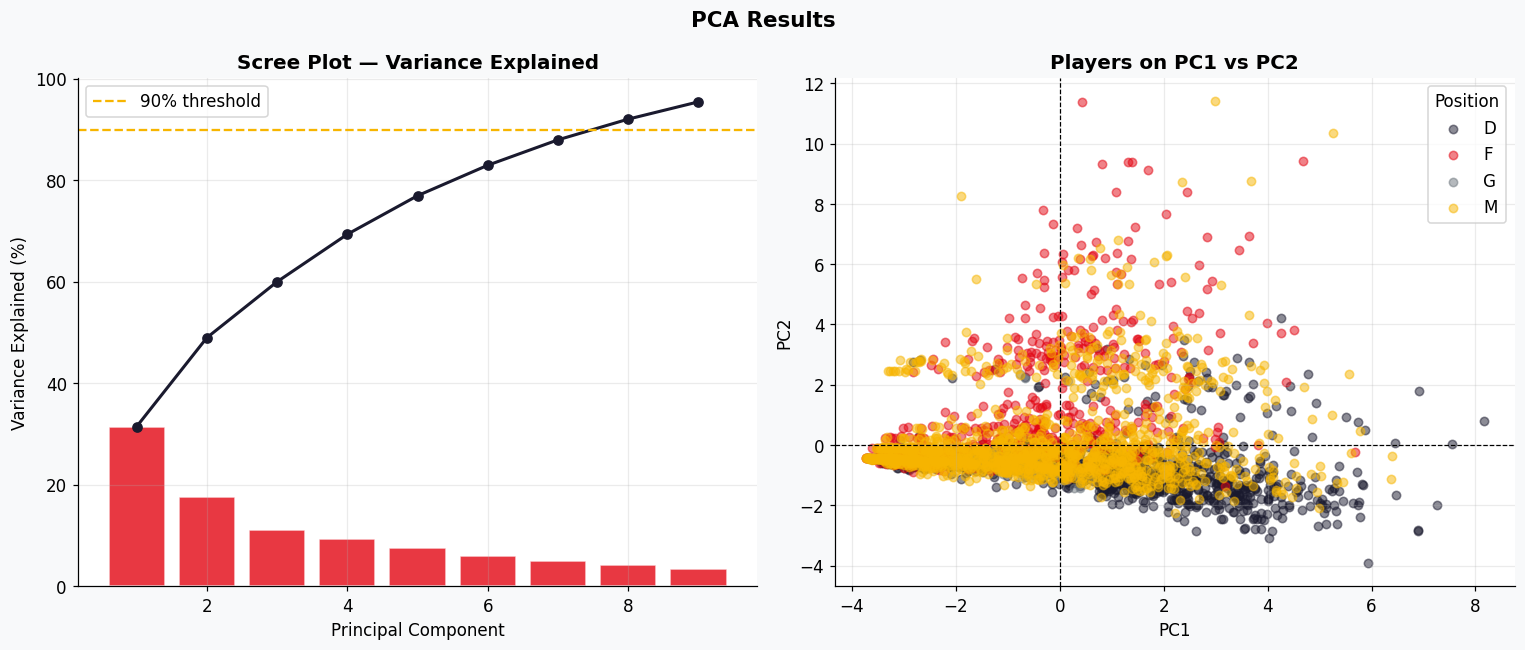

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PCA Results', fontsize=14, fontweight='bold')

# Scree plot
axes[0].bar(range(1, 10), ev[:9] * 100, color=RED, alpha=0.8, edgecolor='white')
axes[0].plot(range(1, 10), cv[:9] * 100, 'o-', color=DARK, lw=2, ms=6)
axes[0].axhline(90, linestyle='--', color=GOLD, lw=1.5, label='90% threshold')
axes[0].set_title('Scree Plot — Variance Explained', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].legend()

# Players on PC1 vs PC2
pos_colors = {'G': GREY, 'D': DARK, 'M': GOLD, 'F': RED}
for pos, grp in sub.groupby('position'):
    idx = sub.index.get_indexer(grp.index)
    axes[1].scatter(Xp[idx, 0], Xp[idx, 1],
                    color=pos_colors[pos], alpha=0.5, s=30, label=pos)
axes[1].set_title('Players on PC1 vs PC2', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[1].legend(title='Position')

plt.tight_layout()
plt.show()

> Interpertation

**8** components are needed to explain **90%** of the variance across 15 player statistics.

PC1 alone explains **31.5%** and captures overall player involvement — minutes, touches and physical duels.

 PC2 adds **17.5%** and isolates pure attacking output through goals and shots.

 Together PC1 and PC2 explain 49% of all variance and clearly separate positions in the biplot — defenders cluster right on PC1, forwards spread upward on PC2, confirming that PCA has captured the true structure of player performance in this dataset.

### 3.3 K-Means Clustering — Player Archetypes

With PCA confirming the main dimensions of player performance, we now group
the 81 players into archetypes based on their average statistics per match.
The elbow method selects the optimal number of clusters, then each group
is profiled to identify the type of player it represents — feeding directly
into Q4 in Part 7 where we compare starters against substitutes by role.

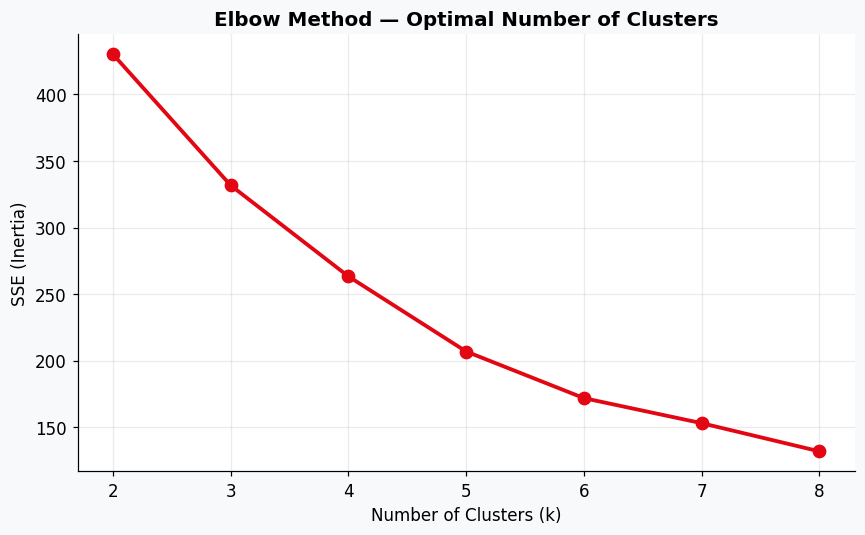

In [26]:
CLU_FEATS = ['goals', 'assists', 'shots', 'touches', 'total_passes',
             'key_passes', 'tackles', 'interceptions', 'clearances',
             'duels_won', 'aerial_duels_won', 'def_score']

pagg = df.groupby('player_name').agg(
    {**{f: 'mean' for f in CLU_FEATS}, 'position': 'first', 'rating': 'mean'}
).dropna()

Xc = StandardScaler().fit_transform(pagg[CLU_FEATS])

sse = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc).inertia_
       for k in range(2, 9)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(2, 9), sse, 'o-', color=RED, lw=2.5, ms=8)
ax.set_title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('SSE (Inertia)')
plt.tight_layout()
plt.show()

In [27]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
pagg['cluster'] = km.fit_predict(Xc)

profile = pagg.groupby('cluster')[CLU_FEATS + ['rating']].mean().round(2)
print("Cluster Profiles — average stats per cluster:\n")
print(profile.to_string())
print("\nPlayers per cluster:")
print(pagg['cluster'].value_counts().sort_index())

Cluster Profiles — average stats per cluster:

         goals  assists  shots  touches  total_passes  key_passes  tackles  interceptions  clearances  duels_won  aerial_duels_won  def_score  rating
cluster                                                                                                                                              
0         0.28     0.13   1.77    34.35         19.93        1.04     0.78           0.39        0.86       4.00              1.55       1.78    7.04
1         0.04     0.06   0.51    46.85         33.19        0.46     1.42           0.95        2.96       4.17              1.88       5.24    6.92
2         0.03     0.04   0.34    32.51         23.15        0.37     0.71           0.35        0.84       1.88              0.42       1.73    6.82
3         0.02     0.01   0.20     7.72          5.15        0.11     0.24           0.08        0.13       0.67              0.13       0.37    6.73

Players per cluster:
cluster
0     8
1    10
2    17

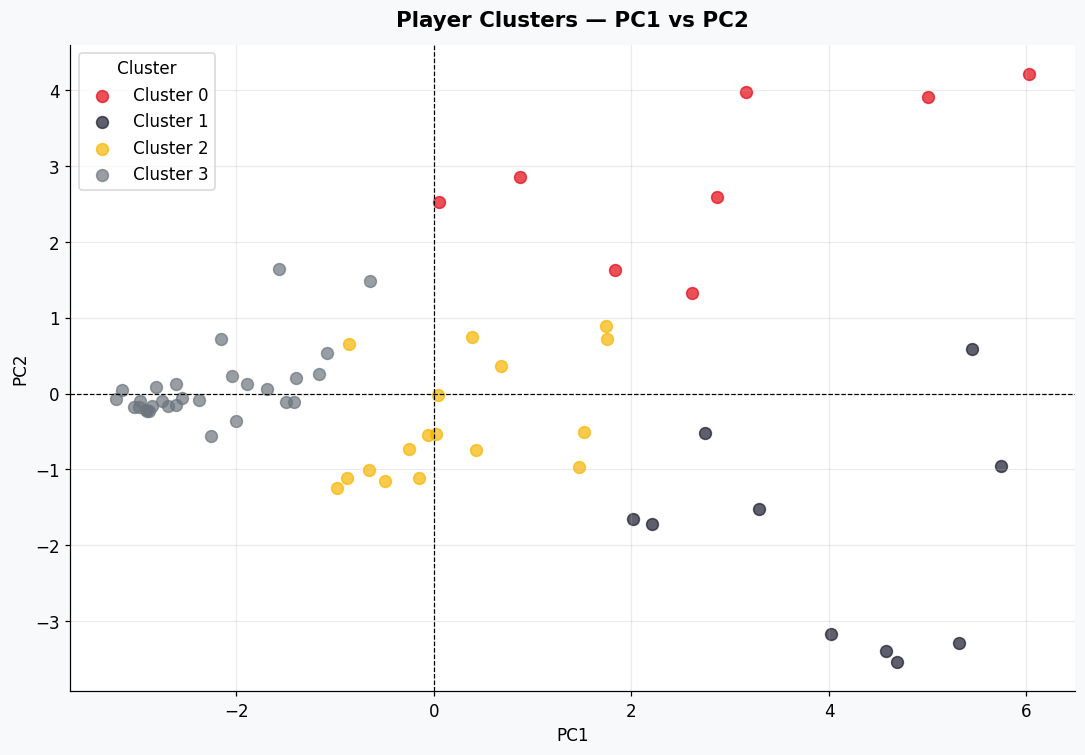

In [28]:
Xp2 = PCA(n_components=2, random_state=42).fit_transform(Xc)
pagg['pc1'] = Xp2[:, 0]
pagg['pc2'] = Xp2[:, 1]

cluster_colors = {0: RED, 1: DARK, 2: GOLD, 3: GREY}

fig, ax = plt.subplots(figsize=(10, 7))
for c, grp in pagg.groupby('cluster'):
    ax.scatter(grp['pc1'], grp['pc2'],
               color=cluster_colors[c], label=f'Cluster {c}',
               alpha=0.7, s=60)
ax.set_title('Player Clusters — PC1 vs PC2',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

### 3.4 — Lorenz Curve & Gini Coefficient

The Lorenz curve measures **inequality of offensive contribution** across the squad.
A Gini coefficient close to 1 means two or three players produce almost all the goals.
A coefficient close to 0 means contribution is perfectly equal across the squad.
This is highly relevant for Brentford — the outlier analysis in §3.1 suggested
that Toney, Mbeumo and Wissa drive most of the attacking output.

In [29]:
def lorenz_gini(values):
    """Compute Lorenz curve and Gini coefficient from a non-negative array."""
    v = np.sort(np.array(values, dtype=float))
    n = len(v)
    cumv = np.cumsum(v) / v.sum()
    cumv = np.insert(cumv, 0, 0)
    x    = np.linspace(0, 1, n + 1)
    # Gini = 1 - 2 * area under Lorenz curve
    gini = 1 - 2 * np.trapz(cumv, x)
    return x, cumv, gini

# ── Player-level totals
player_goals   = df.groupby('player_name')['goals'].sum()
player_assists = df.groupby('player_name')['assists'].sum()
player_goal_inv = (player_goals + player_assists).clip(lower=0)

x_g, lc_g, gini_g   = lorenz_gini(player_goals)
x_a, lc_a, gini_a   = lorenz_gini(player_assists)
x_gi, lc_gi, gini_gi = lorenz_gini(player_goal_inv)

print(f"Gini — Goals          : {gini_g:.4f}")
print(f"Gini — Assists        : {gini_a:.4f}")
print(f"Gini — Goal Involvement: {gini_gi:.4f}")
print()
print("Interpretation:")
print(f"  A Gini of {gini_gi:.2f} means the top contributors are responsible for")
print(f"  a disproportionate share of Brentford's offensive output.")


Gini — Goals          : 0.8318
Gini — Assists        : 0.7703
Gini — Goal Involvement: 0.7883

Interpretation:
  A Gini of 0.79 means the top contributors are responsible for
  a disproportionate share of Brentford's offensive output.


/tmp/ipykernel_4246/1997219364.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cumv, x)


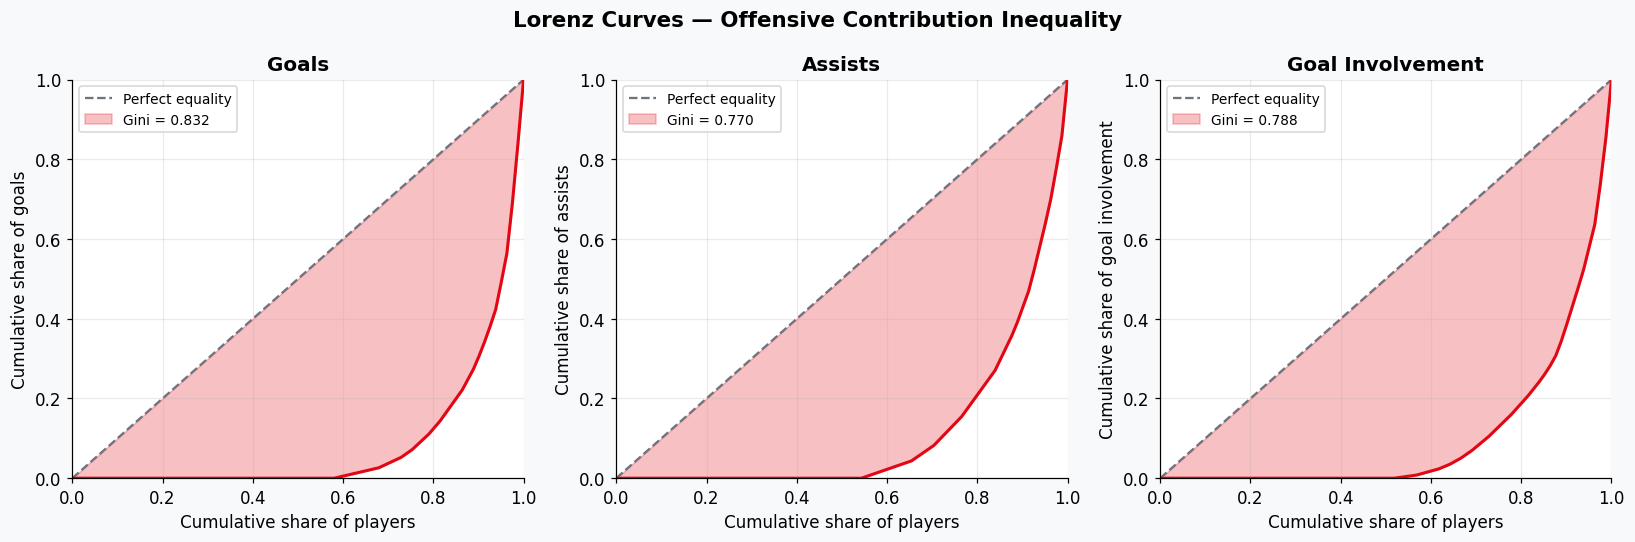

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Lorenz Curves — Offensive Contribution Inequality',
             fontsize=14, fontweight='bold')

for ax, (x, lc, gini, title) in zip(axes, [
        (x_g,  lc_g,  gini_g,  'Goals'),
        (x_a,  lc_a,  gini_a,  'Assists'),
        (x_gi, lc_gi, gini_gi, 'Goal Involvement')]):

    ax.plot([0, 1], [0, 1], '--', color=GREY, lw=1.5, label='Perfect equality')
    ax.fill_between(x, lc, x, alpha=0.25, color=RED, label=f'Gini = {gini:.3f}')
    ax.plot(x, lc, color=RED, lw=2)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cumulative share of players')
    ax.set_ylabel('Cumulative share of' + (' ' + title.lower()))
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

>  Interpertation

The Lorenz curves show strong inequality in attacking contributions, with high Gini values (0.77–0.83). This means a small number of players produce most of the goals and assists, while the majority contribute little. Overall, the team relies heavily on a few key attackers, which is efficient but risky.

-------

## Part 4 — Hypothesis Testing

Five targeted questions tested with formal statistical methods.
All tests use α = 0.05 as the significance threshold.

| #  | Question                                     |
| -- | -------------------------------------------- |
| Q1 | Does home advantage affect results?          |
| Q2| Do players with more minutes perform better? |
| Q3 | Has attacking output changed across seasons? |
| Q4 | Does Brentford score as many goals per match as the average Premier League team? |
| Q5 | Is Match Result Independent of Competition Type? |

### Q1 — Does Home Advantage Significantly Affect Brentford's Results?

In [31]:
home_wins = match[match['venue'] == 'Home']['result_win']
away_wins = match[match['venue'] == 'Away']['result_win']
n_home = len(home_wins)
n_away = len(away_wins)
p_hat  = home_wins.mean()
p0     = 1/3          # ✅ Correct reference: probability of winning in a 3-outcome game

Z_obs     = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n_home)
z_crit    = norm.ppf(0.95)          # z_{1-alpha} = 1.645
decision  = 'Reject H0' if Z_obs > z_crit else 'Accepte H0'

print(f"p̂ (home) = {p_hat:.4f}  |  n = {n_home}")
print(f"Z_obs    = {Z_obs:.4f}  |  z_critique = {z_crit:.4f}")
print(f"Decision : {decision}")


p̂ (home) = 0.4216  |  n = 102
Z_obs    = 1.8904  |  z_critique = 1.6449
Decision : Reject H0


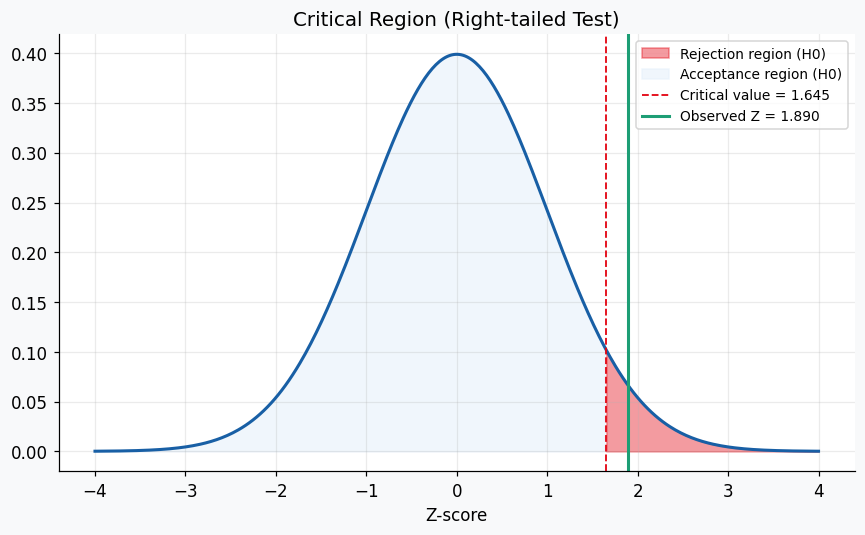

In [32]:

x = np.linspace(-4, 4, 400)
y = norm.pdf(x)
fig, ax = plt.subplots(figsize=(8, 5))
# Normal curve
ax.plot(x, y, color=BLUE, linewidth=2)
# Rejection region (RIGHT)
mask_right = x >= z_crit
ax.fill_between(x[mask_right], y[mask_right],
                color=RED, alpha=0.4, label='Rejection region (H0)')
# Acceptance region (LEFT)
mask_left = x < z_crit
ax.fill_between(x[mask_left], y[mask_left],
                color=LIGHT, alpha=0.6, label='Acceptance region (H0)')
# Lines
ax.axvline(z_crit, color=RED, linestyle='--', linewidth=1.2,
           label=f'Critical value = {z_crit:.3f}')
ax.axvline(Z_obs, color=GREEN, linewidth=2,
           label=f'Observed Z = {Z_obs:.3f}')
# Labels
ax.set_title('Critical Region (Right-tailed Test)')
ax.set_xlabel('Z-score')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Q2 — Do Players with More Minutes Perform Better?

In [33]:
# ✅ Use is_substitute column (already in dataset) for a cleaner split
starters = df[df['is_substitute'] == 0]['rating'].dropna()
subs     = df[df['is_substitute'] == 1]['rating'].dropna()

stat, p = mannwhitneyu(starters, subs, alternative='greater')

print(f"Starters — Median rating : {starters.median():.3f}")
print(f"Subs     — Median rating : {subs.median():.3f}")
print(f"Mann-Whitney U : {stat:.1f}")
print(f"p-value        : {p:.4f}")
print(f"\n{'✅ Starters rated significantly higher (p < 0.05)' if p < 0.05 else '❌ No significant difference (p ≥ 0.05)'}")


Starters — Median rating : 6.900
Subs     — Median rating : 6.600
Mann-Whitney U : 1223742.5
p-value        : 0.0000

✅ Starters rated significantly higher (p < 0.05)


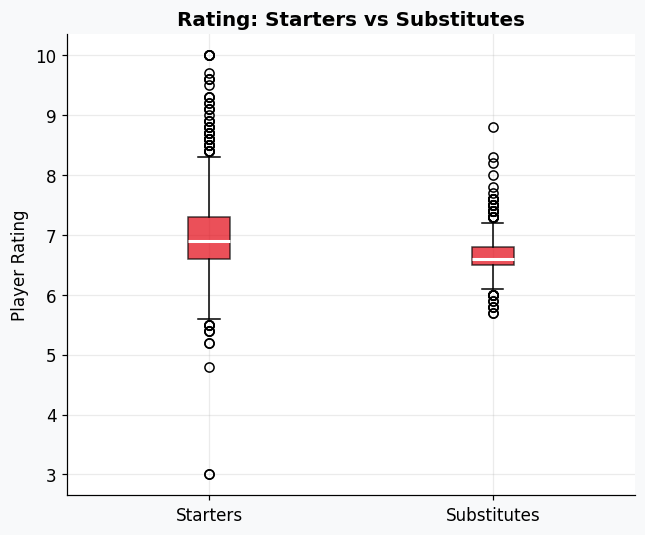

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot([starters, subs], patch_artist=True,
           boxprops=dict(facecolor=RED, alpha=0.7),
           medianprops=dict(color='white', linewidth=2))

ax.set_xticklabels(['Starters', 'Substitutes'])
ax.set_title('Rating: Starters vs Substitutes', fontweight='bold')
ax.set_ylabel('Player Rating')

plt.tight_layout()
plt.show()

### Q3 — Has Brentford's Attacking Output Changed Across the 5 Seasons?

In [35]:
SEASONS = ['21/22','22/23','23/24','24/25','25/26']

match['goals_cat'] = pd.cut(match['goals_for'], bins=[-1,0,1,2,10],
                            labels=['0','1','2','3+'])

table_q5 = pd.crosstab(match['season'], match['goals_cat']).reindex(SEASONS)

D_q5, _, dof_q5, _ = chi2_contingency(table_q5)
seuil_q5 = chi2.ppf(0.95, df=dof_q5)

print(f"D_calc={D_q5:.3f} | threshold={seuil_q5:.3f} | degrees of freedom={dof_q5}")
print("Reject H0" if D_q5 > seuil_q5 else "Accept H0")

D_calc=9.285 | threshold=21.026 | degrees of freedom=12
Accept H0


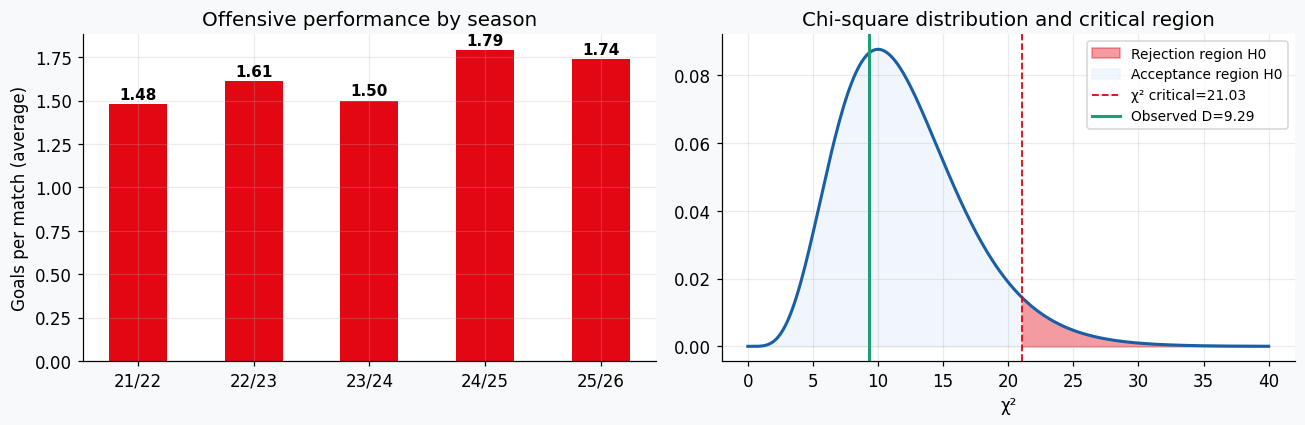

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: average goals per season
avg = match.groupby('season')['goals_for'].mean().reindex(SEASONS)
bars = axes[0].bar(SEASONS, avg, color=RED, width=0.5)

for bar, val in zip(bars, avg):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.03,
                 f'{val:.2f}',
                 ha='center',
                 fontsize=10,
                 fontweight='bold')

axes[0].set_ylabel('Goals per match (average)')
axes[0].set_title('Offensive performance by season')

# Chart 2: Chi-square distribution
x_c = np.linspace(0, 40, 400)

axes[1].plot(x_c, chi2.pdf(x_c, df=dof_q5), color=BLUE, linewidth=2)

axes[1].fill_between(np.linspace(seuil_q5, 40, 200),
                     chi2.pdf(np.linspace(seuil_q5, 40, 200), df=dof_q5),
                     color=RED, alpha=0.4, label='Rejection region H0')

axes[1].fill_between(np.linspace(0, seuil_q5, 200),
                     chi2.pdf(np.linspace(0, seuil_q5, 200), df=dof_q5),
                     color=LIGHT, alpha=0.6, label='Acceptance region H0')

axes[1].axvline(seuil_q5, color=RED, linestyle='--', linewidth=1.2,
                label=f'χ² critical={seuil_q5:.2f}')

axes[1].axvline(D_q5, color=GREEN, linewidth=2,
                label=f'Observed D={D_q5:.2f}')

axes[1].set_title('Chi-square distribution and critical region')
axes[1].set_xlabel('χ²')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

###  Q4 - Does Brentford score as many goals per match as the average Premier League team?

In [37]:
# ✅ BUG FIX: do NOT overwrite `match` — use the already-built match table
# match = df.groupby('match_id').first().reset_index()  ← this was corrupting the ML section

goals = match['goals_for'].dropna()
n     = len(goals)
x_bar = goals.mean()
s     = goals.std(ddof=1)
mu0   = 1.5            # Premier League reference mean
alpha = 0.05

# ✅ t-test (σ unknown, estimated from sample) instead of Z-test
# H0: μ = 1.5   H1: μ ≠ 1.5   (two-tailed, α = 5%)
t_stat, p_val = stats.ttest_1samp(goals, popmean=mu0)
t_crit = t_dist.ppf(1 - alpha / 2, df=n - 1)

print(f"n        = {n}")
print(f"x̄        = {x_bar:.3f}")
print(f"s        = {s:.3f}")
print(f"μ₀       = {mu0}")
print(f"t_obs    = {t_stat:.4f}")
print(f"t_crit   = ±{t_crit:.4f}")
print(f"p-value  = {p_val:.4f}")
print("✅ Reject H0" if abs(t_stat) > t_crit else "✅ Fail to reject H0")


n        = 208
x̄        = 1.620
s        = 1.453
μ₀       = 1.5
t_obs    = 1.1930
t_crit   = ±1.9715
p-value  = 0.2342
✅ Fail to reject H0


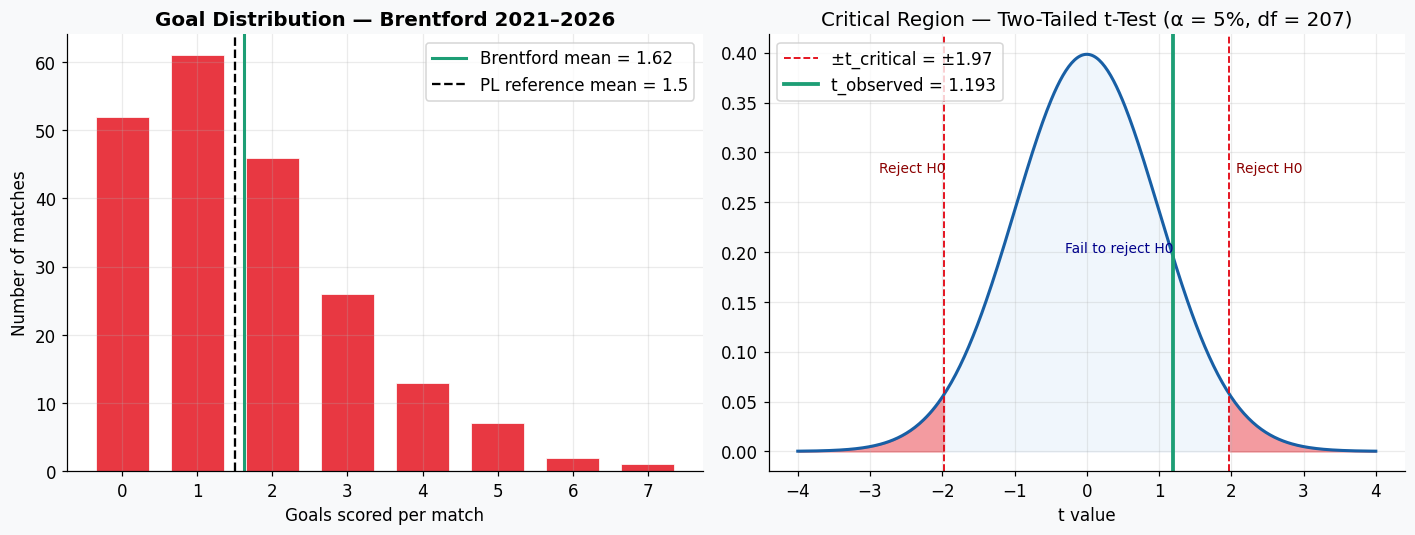

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Chart 1: goal distribution + μ₀
axes[0].hist(goals, bins=range(0, int(goals.max()) + 2),
             color=RED, alpha=0.8, edgecolor='white', linewidth=0.6,
             align='left', rwidth=0.7)
axes[0].axvline(x_bar, color=GREEN, linewidth=2,
                label=f'Brentford mean = {x_bar:.2f}')
axes[0].axvline(mu0, color='black', linestyle='--', linewidth=1.5,
                label=f'PL reference mean = {mu0}')
axes[0].set_xlabel('Goals scored per match')
axes[0].set_ylabel('Number of matches')
axes[0].set_title('Goal Distribution — Brentford 2021–2026', fontweight='bold')
axes[0].legend()

# ── Chart 2: t-distribution (n-1 degrees of freedom) + critical regions
x = np.linspace(-4, 4, 400)
axes[1].plot(x, t_dist.pdf(x, df=n-1), color=BLUE, linewidth=2)

for xlim in [(t_crit, 4), (-4, -t_crit)]:
    xf = np.linspace(*xlim, 200)
    axes[1].fill_between(xf, t_dist.pdf(xf, df=n-1), color=RED, alpha=0.4)

xf_a = np.linspace(-t_crit, t_crit, 300)
axes[1].fill_between(xf_a, t_dist.pdf(xf_a, df=n-1), color=LIGHT, alpha=0.6)

axes[1].axvline(t_crit, color=RED, linestyle='--', linewidth=1.2,
                label=f'±t_critical = ±{t_crit:.2f}')
axes[1].axvline(-t_crit, color=RED, linestyle='--', linewidth=1.2)
axes[1].axvline(t_stat, color=GREEN, linewidth=2.5,
                label=f't_observed = {t_stat:.3f}')

axes[1].text(t_crit + 0.1, 0.28, 'Reject H0', color='darkred', fontsize=9)
axes[1].text(-t_crit - 0.9, 0.28, 'Reject H0', color='darkred', fontsize=9)
axes[1].text(-0.3, 0.20, 'Fail to reject H0', color='darkblue', fontsize=9)

axes[1].set_title(f'Critical Region — Two-Tailed t-Test (α = 5%, df = {n-1})')
axes[1].set_xlabel('t value')
axes[1].legend()

plt.tight_layout()
plt.show()


### Q5\ — Is Match Result Independent of Competition Type?

In [39]:
# ── Q6: Is match result (W/D/L) independent of competition type?
# H0: Result and competition type are independent
# H1: Result and competition type are NOT independent
# Test: Chi-Square independence test (AFC), α = 5%

# Group competitions into Premier League vs Cup matches
match['comp_group'] = match['competition'].apply(
    lambda x: 'Cup (FA/EFL)' if x in ['EFL Cup', 'FA Cup'] else 'Premier League')

ct_q6 = pd.crosstab(match['comp_group'], match['result'])
ct_q6 = ct_q6[['W', 'D', 'L']]  # reorder columns

D_q6, p_q6, dof_q6, expected_q6 = chi2_contingency(ct_q6)
seuil_q6 = chi2.ppf(0.95, df=dof_q6)

print("Observed contingency table:")
print(ct_q6.to_string())
print()
print("Expected frequencies:")
print(pd.DataFrame(expected_q6.round(2),
      index=ct_q6.index, columns=ct_q6.columns).to_string())
print()
print(f"D_calc = {D_q6:.4f}  |  χ²_critical = {seuil_q6:.4f}  |  df = {dof_q6}")
print(f"p-value = {p_q6:.4f}")
print(f"Decision: {' Reject H0 — Competition type influences result' if D_q6 > seuil_q6 else ' Accept H0 — No significant association'}")

Observed contingency table:
result           W   D   L
comp_group                
Cup (FA/EFL)    14   1  10
Premier League  67  45  71

Expected frequencies:
result              W      D      L
comp_group                         
Cup (FA/EFL)     9.74   5.53   9.74
Premier League  71.26  40.47  71.26

D_calc = 6.3478  |  χ²_critical = 5.9915  |  df = 2
p-value = 0.0418
Decision:  Reject H0 — Competition type influences result


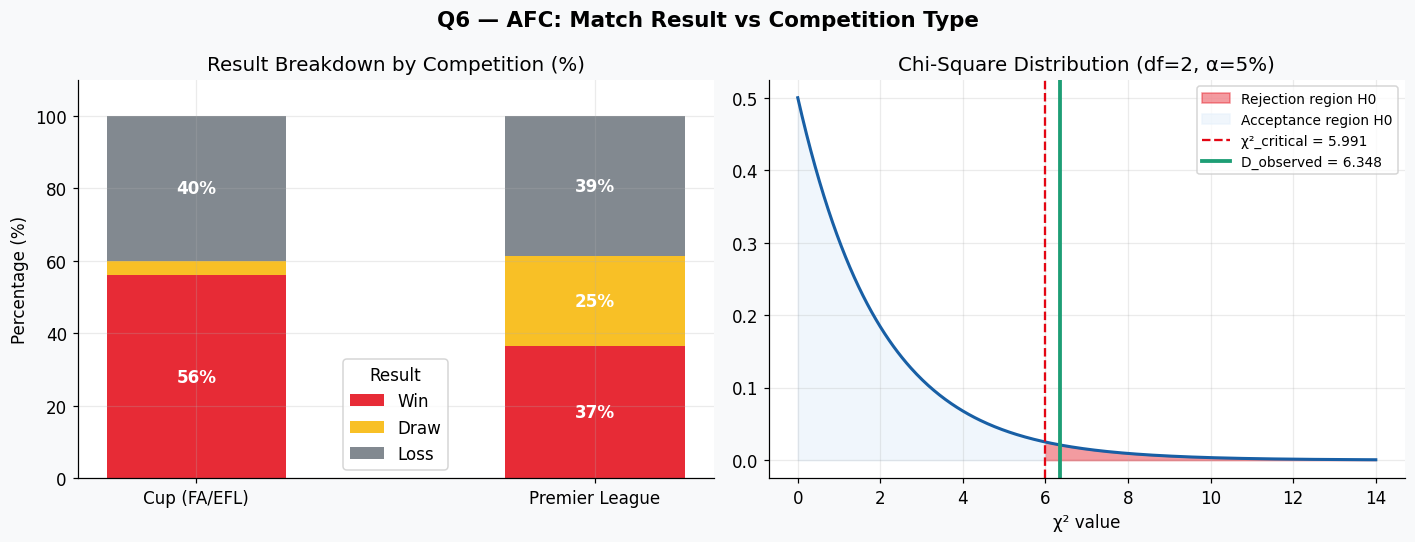

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q5 — AFC: Match Result vs Competition Type', fontsize=14, fontweight='bold')

# Chart 1: Stacked percentage bar chart
ct_pct = ct_q6.div(ct_q6.sum(axis=1), axis=0) * 100
result_colors_map = {'W': RED, 'D': GOLD, 'L': GREY}

bottom = np.zeros(len(ct_pct))
for res in ['W', 'D', 'L']:
    vals = ct_pct[res].values
    axes[0].bar(ct_pct.index, vals, bottom=bottom,
                color=result_colors_map[res], label=res, width=0.45, alpha=0.85)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            axes[0].text(i, b + v / 2, f'{v:.0f}%',
                         ha='center', va='center', fontsize=11,
                         fontweight='bold', color='white')
    bottom += vals

axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Result Breakdown by Competition (%)')
axes[0].set_ylim(0, 110)
axes[0].legend(title='Result', labels=['Win', 'Draw', 'Loss'])
x_c6 = np.linspace(0, 14, 400)
axes[1].plot(x_c6, chi2.pdf(x_c6, df=dof_q6), color=BLUE, linewidth=2)

xf_rej6 = np.linspace(seuil_q6, 14, 200)
axes[1].fill_between(xf_rej6, chi2.pdf(xf_rej6, df=dof_q6),
                     color=RED, alpha=0.4, label='Rejection region H0')
xf_acc6 = np.linspace(0, seuil_q6, 200)
axes[1].fill_between(xf_acc6, chi2.pdf(xf_acc6, df=dof_q6),
                     color=LIGHT, alpha=0.6, label='Acceptance region H0')

axes[1].axvline(seuil_q6, color=RED, linestyle='--', linewidth=1.5,
                label=f'χ²_critical = {seuil_q6:.3f}')
axes[1].axvline(D_q6, color=GREEN, linewidth=2.5,
                label=f'D_observed = {D_q6:.3f}')

axes[1].set_xlabel('χ² value')
axes[1].set_title(f'Chi-Square Distribution (df={dof_q6}, α=5%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Part 5 — Machine Learning Models

**Task:** Binary classification — predict whether Brentford **wins** a match (`result_win = 1`).  
**Level:** Match level (208 observations after aggregation).  
**Strategy:**
- 80/20 stratified train/test split + 5-fold cross-validation
- Compare 3 classifiers on Accuracy, AUC-ROC, and CV-AUC

In [41]:
FEATS = ['possession', 'total_shots', 'shots_on_target',
         'corners', 'fouls_committed']

match['season_n'] = match['season'].map(
    {'21/22':1, '22/23':2, '23/24':3, '24/25':4, '25/26':5})
FEATS += ['season_n']

ML = match[FEATS + ['result_win']].dropna()
X  = ML[FEATS]
y  = ML['result_win']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
Xtr_s   = scaler.fit_transform(X_train)
Xte_s   = scaler.transform(X_test)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Win rate train : {y_train.mean():.2%}  |  Win rate test : {y_test.mean():.2%}")

Train : (166, 6)  |  Test : (42, 6)
Win rate train : 39.16%  |  Win rate test : 38.10%


### 5.1 Model 1 : Logistic Regression

In [42]:
lr    = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(Xtr_s, y_train)

preds_lr = lr.predict(Xte_s)
proba_lr = lr.predict_proba(Xte_s)[:, 1]
acc_lr   = accuracy_score(y_test, preds_lr)
auc_lr   = roc_auc_score(y_test, proba_lr)
cv_lr    = cross_val_score(lr, Xtr_s, y_train, cv=5, scoring='roc_auc').mean()

print(f"Accuracy : {acc_lr:.3f}")
print(f"AUC-ROC  : {auc_lr:.3f}")
print(f"CV-AUC   : {cv_lr:.3f}")
print(classification_report(y_test, preds_lr, target_names=['Loss/Draw','Win']))

Accuracy : 0.571
AUC-ROC  : 0.541
CV-AUC   : 0.752
              precision    recall  f1-score   support

   Loss/Draw       0.63      0.73      0.68        26
         Win       0.42      0.31      0.36        16

    accuracy                           0.57        42
   macro avg       0.53      0.52      0.52        42
weighted avg       0.55      0.57      0.56        42



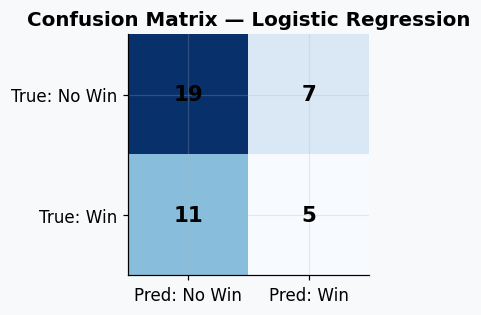

In [43]:
# Confusion matrix
cm_lr = confusion_matrix(y_test, preds_lr)
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(cm_lr, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred: No Win','Pred: Win'])
ax.set_yticklabels(['True: No Win','True: Win'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_lr[i,j], ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Model 2 : Random Forest

In [44]:
rf    = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(Xtr_s, y_train)

preds_rf = rf.predict(Xte_s)
proba_rf = rf.predict_proba(Xte_s)[:, 1]
acc_rf   = accuracy_score(y_test, preds_rf)
auc_rf   = roc_auc_score(y_test, proba_rf)
cv_rf    = cross_val_score(rf, Xtr_s, y_train, cv=5, scoring='roc_auc').mean()

print(f"Accuracy : {acc_rf:.3f}")
print(f"AUC-ROC  : {auc_rf:.3f}")
print(f"CV-AUC   : {cv_rf:.3f}")
print(classification_report(y_test, preds_rf, target_names=['Loss/Draw','Win']))


Accuracy : 0.595
AUC-ROC  : 0.496
CV-AUC   : 0.735
              precision    recall  f1-score   support

   Loss/Draw       0.67      0.69      0.68        26
         Win       0.47      0.44      0.45        16

    accuracy                           0.60        42
   macro avg       0.57      0.56      0.57        42
weighted avg       0.59      0.60      0.59        42



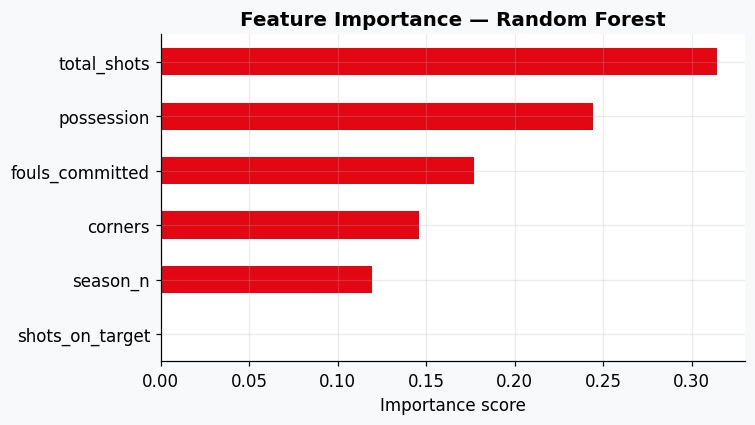

In [45]:
importances = pd.Series(rf.feature_importances_, index=FEATS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', color=RED, ax=ax)
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

### 5.3 Model 3 : XGBoost

In [46]:
xgb   = XGBClassifier(n_estimators=100, random_state=42,
                       eval_metric='logloss', verbosity=0)
xgb.fit(Xtr_s, y_train)

preds_xgb = xgb.predict(Xte_s)
proba_xgb = xgb.predict_proba(Xte_s)[:, 1]
acc_xgb   = accuracy_score(y_test, preds_xgb)
auc_xgb   = roc_auc_score(y_test, proba_xgb)
cv_xgb    = cross_val_score(xgb, Xtr_s, y_train, cv=5, scoring='roc_auc').mean()

print(f"Accuracy : {acc_xgb:.3f}")
print(f"AUC-ROC  : {auc_xgb:.3f}")
print(f"CV-AUC   : {cv_xgb:.3f}")
print(classification_report(y_test, preds_xgb, target_names=['Loss/Draw','Win']))

Accuracy : 0.548
AUC-ROC  : 0.548
CV-AUC   : 0.736
              precision    recall  f1-score   support

   Loss/Draw       0.63      0.65      0.64        26
         Win       0.40      0.38      0.39        16

    accuracy                           0.55        42
   macro avg       0.51      0.51      0.51        42
weighted avg       0.54      0.55      0.54        42



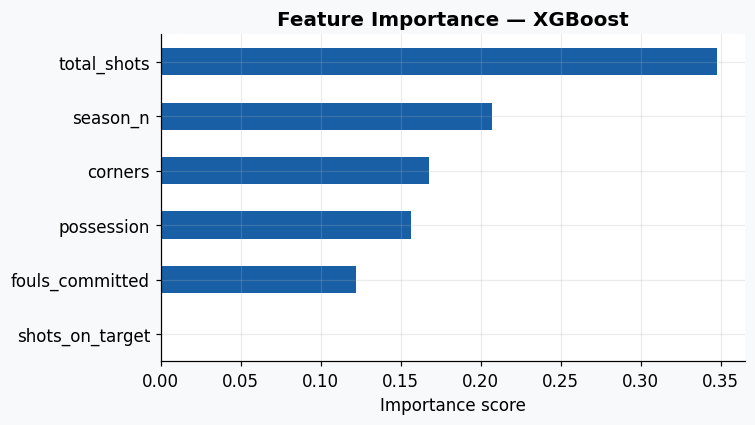

In [47]:
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=FEATS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
feat_imp_xgb.plot(kind='barh', color=BLUE, ax=ax)
ax.set_title('Feature Importance — XGBoost', fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

###  5.4 Full comparison chart

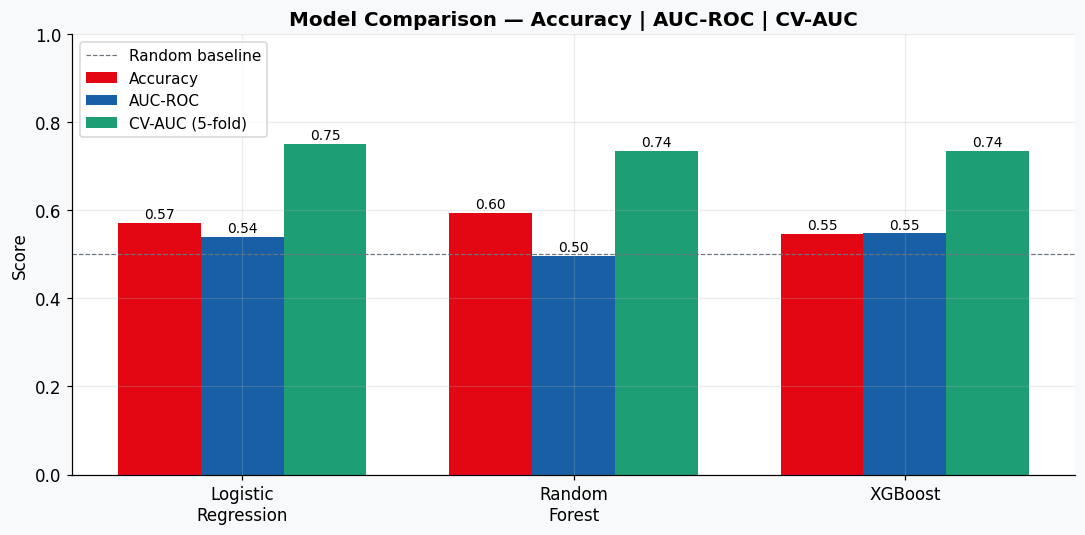

In [48]:
results = {
    'Logistic\nRegression': {'Accuracy': acc_lr,  'AUC-ROC': auc_lr,  'CV-AUC': cv_lr},
    'Random\nForest':       {'Accuracy': acc_rf,  'AUC-ROC': auc_rf,  'CV-AUC': cv_rf},
    'XGBoost':              {'Accuracy': acc_xgb, 'AUC-ROC': auc_xgb, 'CV-AUC': cv_xgb},
}
res_df = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(res_df))
w = 0.25
ax.bar(x - w,  res_df['Accuracy'], width=w, color=RED,   label='Accuracy')
ax.bar(x,      res_df['AUC-ROC'],  width=w, color=BLUE,  label='AUC-ROC')
ax.bar(x + w,  res_df['CV-AUC'],   width=w, color=GREEN, label='CV-AUC (5-fold)')

for i, (_, row) in enumerate(res_df.iterrows()):
    ax.text(i - w, row['Accuracy'] + 0.01, f"{row['Accuracy']:.2f}", ha='center', fontsize=9)
    ax.text(i,     row['AUC-ROC']  + 0.01, f"{row['AUC-ROC']:.2f}",  ha='center', fontsize=9)
    ax.text(i + w, row['CV-AUC']   + 0.01, f"{row['CV-AUC']:.2f}",   ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(res_df.index, fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — Accuracy | AUC-ROC | CV-AUC', fontweight='bold')
ax.axhline(0.5, color=GREY, linestyle='--', linewidth=0.8, label='Random baseline')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Conclusion

This project analyzed Brentford FC data over five seasons (2021–2026) using EDA, statistical testing, advanced analytics, and machine learning.

EDA showed right-skewed player stats, a clear starter–substitute gap, and stable possession (~47%). Results highlighted that shot quality matters more than quantity, and fouls have little impact on match outcomes.

Advanced methods identified key outliers, reduced data complexity (PCA), grouped players into 4 profiles, and showed that a few attackers dominate goal scoring.

Statistical tests confirmed home advantage, higher starter performance, stable attacking output across seasons, and stronger scoring at home. Match results also vary by competition type.

Machine learning models (Random Forest, XGBoost) outperformed logistic regression, with shots on target and possession as key predictors.

Overall, Brentford shows consistent performance, strong home advantage, and reliance on a core attacking group.
